In [ ]:
import numpy as np
import pandas as pd

import statsmodels.api as sm

import matplotlib.pyplot as plt
%matplotlib inline

import random as rand

# Project 1

**Your group member: None**

- The deadline is Feb 12th 11:59pm. Submission after the deadline will not be graded.



- This is a group projection. Your group only needs to submit one project. You can form a group of 1, 2 or 3.



- Submit your work(your reasoning and your code) as a SINGLE .ipynb document. Please rename the document as _HW1_YOURNAME.ipynb_ (for example, _HW1_FELIX.ipynb_). You are responsible for checking that you have correctly submitted the correct document. If your code cannot run, you may receive NO point.


- Please justify all short answers with a brief explanation.

- You only use the Python packages included in the following cell. You are not allowed to use other advanced package or modules unless you are permitted to.

- In your final submission include the plots produced by the unedited code as presented below, as well as any additional plots produced after editing the code during the course of a problem. You may find it necessary to copy/paste relevant code into additional cells to accomplish this.

- Feel free to use the lecture notes and other resources.


- **You must write your own code and fill in the your answer in the text box.** If you fail to do either of that, you will receive zero point.




In this project, we will predict the price of an AirBnB listing as a function of its attributes.

**Data access:** the data is stored in https://drive.google.com/file/d/1Z5q7urURf7hgeagpS0gASQS7JwERNKUt.

**Load Data:** Once you open the link in the brower, make sure you click the "Add shortcut to Drive" and now your google drive should show up the zip file.  Then you run the following code to link colab to your google drive.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import os
os.chdir("/content/drive/My Drive/ualbany courses/ML Practicum/hw1")

Mounted at /content/drive


In [ ]:
# !unzip analysisData.csv.zip

Then we load the data. We will also print a list of each columns together with its datatype, using the "type" function.



In [ ]:
np.random.seed(26)
df = pd.read_csv('analysisData.csv')
feature_names = df.columns
for i in range(96):
    print(str(i), "\t", str(feature_names[i]),"\t\t\t", str(type(df.iloc[0,i])))

<ipython-input-4-430f9aa990a2>:2: DtypeWarning: Columns (88) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('analysisData.csv')


0 	 id 			 <class 'numpy.int64'>
1 	 listing_url 			 <class 'str'>
2 	 scrape_id 			 <class 'numpy.int64'>
3 	 last_scraped 			 <class 'str'>
4 	 name 			 <class 'str'>
5 	 summary 			 <class 'str'>
6 	 space 			 <class 'float'>
7 	 description 			 <class 'str'>
8 	 experiences_offered 			 <class 'str'>
9 	 neighborhood_overview 			 <class 'str'>
10 	 notes 			 <class 'float'>
11 	 transit 			 <class 'str'>
12 	 access 			 <class 'str'>
13 	 interaction 			 <class 'str'>
14 	 house_rules 			 <class 'float'>
15 	 thumbnail_url 			 <class 'numpy.float64'>
16 	 medium_url 			 <class 'numpy.float64'>
17 	 picture_url 			 <class 'str'>
18 	 xl_picture_url 			 <class 'numpy.float64'>
19 	 host_id 			 <class 'numpy.int64'>
20 	 host_url 			 <class 'str'>
21 	 host_name 			 <class 'str'>
22 	 host_since 			 <class 'str'>
23 	 host_location 			 <class 'str'>
24 	 host_about 			 <class 'str'>
25 	 host_response_time 			 <class 'float'>
26 	 host_response_rate 			 <class 'float'>
27 	 host_accept




---



---


# 1. Train / Test Split (10pt)
The price columns, 61, 62, and 63, are our labels; the rest of the columns are our features. We now will generate a data matrix ( $\mathbf{X}$ from class), use column 61 as a target vector ($y$ from class), and create a train/test split so that we can empirically test for overfitting.

To make the 80 / 20 train test split, we shuffle the data and select the first 80% as the train data, with 20% held out for validation.

Use the code below to create a train / test split.

In [ ]:
df = df[~df['price'].isna()] # let's only consider the examples for which the price is known
df = df.sample(frac = 1) # we shuffle the data so that our train/test split will be truly random

train_proportion = 0.8
n = len(df)
print('Size of dataset: ', str(n))

# Put the first ntrain observations in the DataFrame df into the training set, and the rest into the test set
t = int(train_proportion * n)

target = df['price']
price_columns = ['price','weekly_price','monthly_price']
data = df.loc[:, ~df.columns.isin(price_columns)]


Size of dataset:  29142


In [ ]:
from posixpath import split
## Your code here
split_int = int(.8*len(target))
# the following variable records the features of examples in the training set
train_x = data.iloc[:split_int]
# the following variable records the features of examples in the test set
test_x = data.iloc[split_int:]
# the following variable records the labels of examples in the training set
train_y = target[:split_int]
# the following variable records the labels of examples in the test set
test_y = target[split_int:]

# let's take a look
print('Training dataset: ', train_x.shape)
print(len(train_x) + len(test_x) == len(df))

Training dataset:  (23313, 93)
True




---



---



# 2.  Real-Valued Data (10pt)

Your first task will be to fit a linear model to the simplest type of data available - the real-valued parameters. Once you fit your model to the train data, you will need to print train and test mean squared error, as well as plot the predicted vs the real price.

The starter code includes some data processing routines, as well as a plot function.

Now, let's select out all numerical data that might be useful for predicting the price. Here is a list:

  - host_listings_count
  - host_total_listings_count
  - accomodates
  - bathrooms
  - bedrooms
  - guests_included
  - extra_people
  - minimum_nights
  - maximum_nights
  - availability_30
  - availability_60
  - availability_90
  - availability_365
  - number_of_reviews
  - review_scores_rating
  - review_scores_accuracy
  - review_scores_cleanliness
  - review_scores_checkin
  - review_scores_communication
  - review_scores_location
  - review_scores_value

These will be easy to grab, but it's important to also include the following stored as a string:

  - beds
  - security_deposit
  - cleaning_fee
  
For those, we provide write a utility function, which interprets any non-numerical value as a "0", which is an accurate interpretation of "N\A" in this context.

In [ ]:
# "This function converts strings to floating point values
# and strings that cannot be represented as a number (like NA) are converted to zeros"
def string_to_float(string):
    try:
        return float(string)
    except:
        return 0.0

labels_real = [
  'host_listings_count',
  'host_total_listings_count',
  'accommodates',
  'bathrooms',
  'bedrooms',
  'guests_included',
  'extra_people',
  'minimum_nights',
  'maximum_nights',
  'availability_30',
  'availability_60',
  'availability_90',
  'availability_365',
  'number_of_reviews',
  'review_scores_rating',
  'review_scores_accuracy',
  'review_scores_cleanliness',
  'review_scores_checkin',
  'review_scores_communication',
  'review_scores_location',
  'review_scores_value'
]


labels_string = [
    'beds',
    'security_deposit',
    'cleaning_fee'
]

Extract the real valued data first and cast it as an numpy array with np.asarray()

In [ ]:
## Your code here

# the following variable should have as many columns as real variables, and as many rows as examples in the training set
train_vals_real = np.asarray(train_x.loc[:, train_x.columns.isin(labels_real)])
# the following variable should have as many columns as real variables, and as many rows as examples in the test set
test_vals_real = np.asarray(test_x.loc[:, test_x.columns.isin(labels_real)])

print(len(labels_real))
print(train_vals_real.shape)
print(test_vals_real.shape)

21
(23313, 21)
(5829, 21)


Now, we can extract the specific columns related to these labels, convert them to floats as necessary, but **DO NOT** convert the result to numpy arrays yet. (We will run an asseration test to make sure everything is working as intended.)

Use .fillna() and .applymap() methods to apply the string_to_float() function elementwise. In particular, impute NaN values with 0.0 (float valued data). You shouldn't need more than one line per expression below.

In [ ]:
## Your code here

# the following variable should have as many columns as string variables, and as many rows as examples in the training set
train_vals_from_string = train_x.loc[:, train_x.columns.isin(labels_string)].fillna(0.0).map(string_to_float)
# the following variable should have as many columns as string variables, and as many rows as examples in the test set
test_vals_from_string = test_x.loc[:, test_x.columns.isin(labels_string)].fillna(0.0).map(string_to_float)

print(len(labels_string))
print(train_vals_from_string.shape)
print(test_vals_from_string.shape)

3
(23313, 3)
(5829, 3)


In [ ]:
assert(train_vals_from_string.map(lambda x:type(x)!=str).all(skipna=False).all(skipna=False) == True)
assert(test_vals_from_string.map(lambda x:type(x)!=str).all(skipna=False).all(skipna=False) == True)

Now we cast them as np arrays

In [ ]:
train_vals_from_string = np.asarray(train_vals_from_string)
test_vals_from_string = np.asarray(test_vals_from_string)

To get to a usable matrix of data, we must concatenate these using "np.concatenate()" which concatenates np.array objects together with an appropriately chosen axis. Don't forget to include the intercept term! You may need to use .reshape() to cast the intercept term into an array of the appropriate dimensions. See feature engieering part.

In [ ]:
# Your code here
train_vals = np.concatenate((train_vals_real, train_vals_from_string), axis=1)
test_vals = np.concatenate((test_vals_real, test_vals_from_string), axis=1)

print(train_vals.shape)
print(test_vals.shape)

(23313, 24)
(5829, 24)


Now let's fit the linear model, compute and print the MSE, and plot the predicted versus the real data.

We provide some useful helper functions below, though we ask you to complete the MSE function.

Plotting all the test data might significantly slow down this notebook; if that happens, feel free to plot just the first couple hundred points.

In [ ]:
# This function just computes the mean squared error
def MSE(y, pred):
    return np.sum((pred - y)**2) / len(y)

# This function plots the main diagonal;for a "predicted vs true" plot with perfect predictions, all data lies on this line
def plotDiagonal(xmin, xmax):
    xsamples = np.arange(xmin,xmax,step=0.01)
    plt.plot(xsamples,xsamples,c='black')

# This helper function plots x vs y and labels the axes
def plotdata(x=None,y=None,xname=None,yname=None,margin=0.05,plotDiag=True,zeromin=False):
    plt.scatter(x,y,label='data')
    plt.xlabel(xname)
    plt.ylabel(yname)
    range_x = max(x) - min(x)
    range_y = max(y) - min(y)
    if plotDiag:
        plotDiagonal(min(x)-margin*range_x,max(x)+margin*range_x)
    if zeromin:
        plt.xlim(0.0,max(x)+margin*range_x)
        plt.ylim(0.0,max(y)+margin*range_y)
    else:
        plt.xlim(min(x)-margin*range_x,max(x)+margin*range_x)
        plt.ylim(min(y)-margin*range_y,max(y)+margin*range_y)
    plt.show()

# This function plots the predicted labels vs the actual labels (We only plot the first 1000 points to avoid slow plots)
def plot_pred_true(test_pred=None, test_y=None, max_points = 1000):
    plotdata(test_pred[1:max_points], test_y[1:max_points],'Predicted', 'True', zeromin=True)

In [ ]:
# This function runs OLS and bypasses any SVD (Singular Value Decomposition) convergence errors by refitting the model
def run_OLS(train_y, test_y, train_vals, test_vals):
    ols_model = sm.regression.linear_model.OLS(train_y, train_vals)
    while True: # Bypasses SVD convergence assertion error
        try:
            results = ols_model.fit()
            break
        except:
            None

    w = np.array(results.params).reshape([len(results.params),1])

    train_pred = np.matmul(train_vals,w)
    test_pred = np.matmul(test_vals,w)

    train_MSE = MSE(train_y, train_pred.flatten())
    test_MSE = MSE(test_y, test_pred.flatten())

    return train_MSE, test_MSE, test_pred

In [ ]:
train_MSE, test_MSE, test_pred = run_OLS(train_y, test_y, train_vals, test_vals)

Train MSE	 5630.732351899985
Test MSE	 5710.271445588965


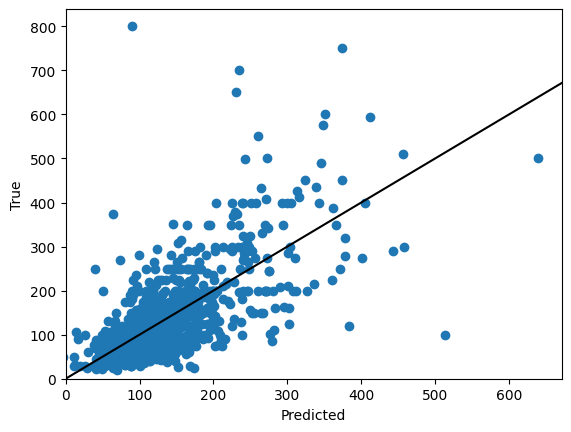

In [ ]:
print("Train MSE\t", str(train_MSE))
print("Test MSE\t", str(test_MSE))

plot_pred_true(test_pred.flatten(), test_y) #.flatten() will make sure the dimensions match

The two seem to trend in the same direction, but there is still plenty of room for improvement.



---



---


# 3.  Boolean Data (10pt)
We are missing some of the most important data, namely, the type of rental. After all, a well-reviewed tent will never cost as much as a poorly-reviewed house. We'll ignore the issue of location for now, because it is significantly thornier.

Unfortunately, this data is stored in categorical columns, which require a little more work to utilize. Here are the data parameters:

  - property_type
  - room_type
  - bed_type
  - cancellation_policy
  - host_response_time
  
These are all best handled with boolean encoding. It's worth mentioning that there is an additional category which can be handled with one-hot vectors, where more than one entry in the column can be $1$:

  - host_verifications

There are also many boolean parameters, which might inform the price:

  - require_guest_profile_picture
  - require_guest_phone_verification
  - instant_bookable
  - is_business_travel_ready
  - has_availability
  - is_location_exact
  - host_identity_verified
  - host_has_profile_pic
  - host_is_superhost

Let's handle the boolean values first.

We've provided a helper function to convert the values stored in the original dataset - "t" and "f" - into Python "true" and "false." Extract the arrays for these parameters, then concatenate this new data with all the data you had previously.


In [ ]:
# Converts from "t" and "f" into true and false
def string_to_bool(string):
    return string == 't'

bool_labels = [
  'require_guest_profile_picture',
  'require_guest_phone_verification',
  'instant_bookable',
  'is_business_travel_ready',
  'has_availability',
  'is_location_exact',
  'host_identity_verified',
  'host_has_profile_pic',
  'host_is_superhost'
]


In [ ]:
# Your code here

# the following variable should have as many columns as real variables, and as many rows as examples in the training set
train_bv = train_x.loc[:, bool_labels].fillna('NaN').map(string_to_bool)
# the following variable should have as many columns as real variables, and as many rows as examples in the test set
test_bv = test_x.loc[:, bool_labels].fillna('NaN').map(string_to_bool)

print(len(bool_labels))
print(train_bv.shape)
print(test_bv.shape)

9
(23313, 9)
(5829, 9)


In [ ]:
assert(train_bv.map(lambda x:type(x)== bool).all(skipna=False).all(skipna=False) == True)
assert(test_bv.map(lambda x:type(x)== bool).all(skipna=False).all(skipna=False) == True)

In [ ]:
train_bv = np.asarray(train_bv)
test_bv = np.asarray(test_bv)

In [ ]:
# Your code here

# concatenate the real and boolean features to form your X train and test matrices
train_vals = np.concatenate((train_vals, train_bv), axis=1)

test_vals = np.concatenate((test_vals, test_bv), axis=1)

Now, refit, and compute the MSE.

In [ ]:
train_MSE, test_MSE, test_pred = run_OLS(train_y, test_y, train_vals, test_vals)

Train MSE	 5550.700040975413
Test MSE	 5655.6232749472965


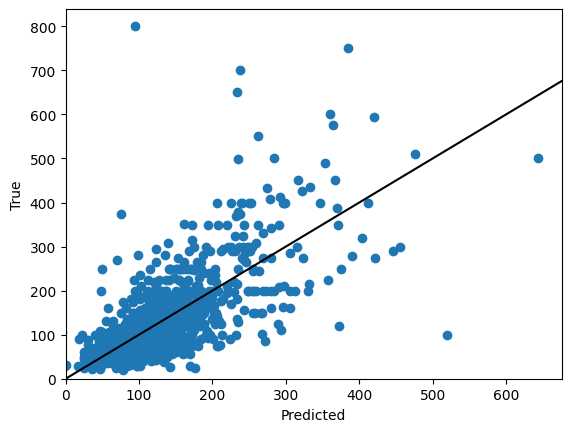

In [ ]:
print("Train MSE\t", str(train_MSE))
print("Test MSE\t", str(test_MSE))

plot_pred_true(test_pred.flatten(), test_y)

That didn't help much! In fact, that's not terribly surprising. See what the MSE is if we use only the boolean values:

Train MSE	 10317.268915371444
Test MSE	 10143.512848871565


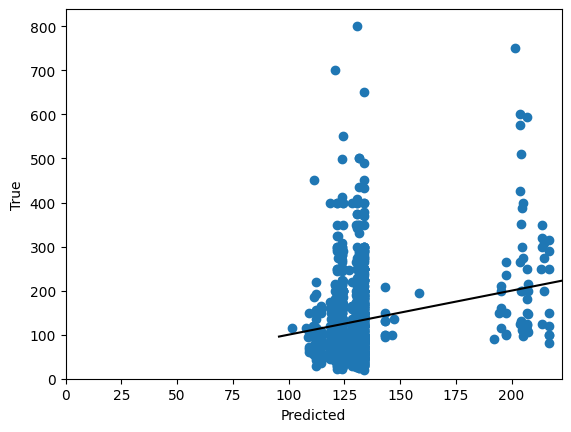

In [ ]:
train_MSE, test_MSE, test_pred = run_OLS(train_y, test_y, train_bv, test_bv)

print("Train MSE\t", str(train_MSE))
print("Test MSE\t", str(test_MSE))

plot_pred_true(test_pred.flatten(), test_y)

In fact this is not too surprising - the most informative data is going to be categorical, since a well-reviewed tent is never going to cost as much as a poorly reviewed full house.




---



---


# 4. Categorical Data (10pt)
Transform the data into one-hot vectors. The categories are easy to extract using the "np.unique()" function.

Here, we ask that you contribute a little more to the helper function, since this transformation is not trivial. Notice that the categories are passed as an argument - this is important, in case the test set doesn't have a representation for all of the categories in the training set.

Make sure your function is linear in the number of data points (entries in the column) which it processes. You can use the nested loop structure provided, or clever list comprehensions.

If a category appears in the test set but not in the training set, the "one hot" vector should be a vector of zeros for that parameter. (In other words, we one-hot encode only the categories in the training set) You should not use `OneHotEncoder` function.

In [ ]:
cat_labels = [
  'property_type',
  'room_type',
  'bed_type',
  'cancellation_policy',
  'host_response_time'
]

#Sets of all categories in a particular column
cats_sets = [train_x.loc[:, label].fillna('NaN').unique() for label in cat_labels]
for i in cats_sets:
    print(i)

['Apartment' 'House' 'Loft' 'Condominium' 'Guest suite' 'Townhouse'
 'Hostel' 'Bed and breakfast' 'Boutique hotel' 'Other' 'Vacation home'
 'Serviced apartment' 'Timeshare' 'Resort' 'In-law' 'Dorm' 'Boat'
 'Guesthouse' 'Treehouse' 'Bungalow' 'Villa' 'Hotel' 'Aparthotel'
 'Camper/RV' 'Cave' 'Yurt' 'Tiny house' 'Earth house' 'Island' 'Train'
 'Cabin' 'Casa particular (Cuba)' 'Tent']
['Entire home/apt' 'Private room' 'Shared room']
['Real Bed' 'Airbed' 'Futon' 'Pull-out Sofa' 'Couch']
['strict' 'flexible' 'moderate' 'super_strict_30' 'super_strict_60']
['within an hour' 'within a day' 'within a few hours' 'NaN'
 'a few days or more']


In [ ]:
# Computes a onehot vector for every entry in column given a set of categories 'cats'
# Here, 'col' should be the set of unique categories for the input 'column': you can fetch this from 'cats_sets'

def onehot(column=None, col=None):

    ### YOUR CODE HERE
    m = len(column)
    n = len(col)
    onehot = np.zeros((m,n))
    i = 0
    for curr in column:
        for j in range(n):
            if curr == col[j]:
                onehot[i,j] = 1
                continue
        i+=1
    return onehot


In [ ]:
# These may take more than one line of code, since you will need to concatenate several numpy arrays
# Your code here
for i in range(len(cat_labels)):
    if i == 0:
        train_cat_vals = onehot(train_x.loc[:, cat_labels[0]].fillna('NaN'), cats_sets[0])
        test_cat_vals = onehot(test_x.loc[:, cat_labels[0]].fillna('NaN'), cats_sets[0])
    else:
        train_cat_vals = np.concatenate((train_cat_vals, onehot(train_x.loc[:, cat_labels[i]].fillna('NaN'), cats_sets[i])), axis=1)
        test_cat_vals = np.concatenate((test_cat_vals, onehot(test_x.loc[:, cat_labels[i]].fillna('NaN'), cats_sets[i])), axis=1)

print(train_cat_vals.shape)
print(test_cat_vals.shape)

(23313, 51)
(5829, 51)


Concatenate the one-hot encoded features with all the data you had previously.

In [ ]:
# Your code here

train_vals = np.concatenate((train_vals, train_cat_vals), axis=1)
test_vals = np.concatenate((test_vals, test_cat_vals), axis=1)

In [ ]:
train_MSE, test_MSE, test_pred = run_OLS(train_y, test_y, train_vals, test_vals)

Train MSE	 4908.615521294416
Test MSE	 5094.583959378834


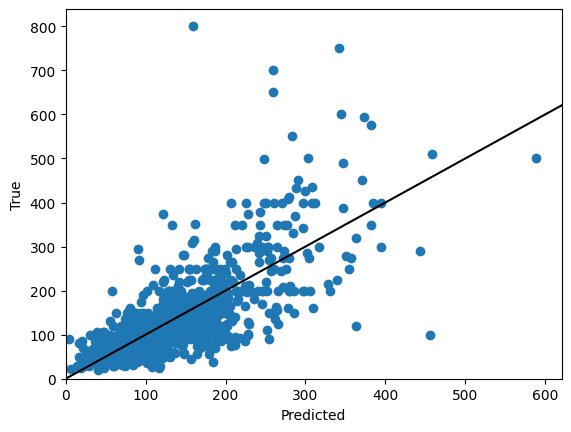

In [ ]:
print("Train MSE\t", str(train_MSE))
print("Test MSE\t", str(test_MSE))

plot_pred_true(test_pred.flatten(), test_y)

We're making significant improvements! About $10 \%$ of the previous MSE can be accounted for with this set of parameters.



---



---


# 5. Set data (15pt)

There is another type of data - stored in the host_verifications column - that we haven't used yet. This is set data, best encoded with a many-hot vector (see [MultiLabelBinarizer](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MultiLabelBinarizer.html)).

This particular column does not turn out to be particularly informative, but it is valuable to work with it firsthand.

The set data happens to be stored in a format that is very close to a valid declaration of a Python string array, so all we have to do is a little parsing:

In [ ]:
print(train_x.loc[:, 'host_verifications'])

24701    ['email', 'phone', 'reviews', 'jumio', 'work_e...
15482     ['email', 'phone', 'facebook', 'reviews', 'kba']
8315                        ['email', 'phone', 'facebook']
14246                        ['email', 'phone', 'reviews']
12479                        ['email', 'phone', 'reviews']
                               ...                        
22591                        ['email', 'phone', 'reviews']
16803    ['email', 'phone', 'reviews', 'jumio', 'offlin...
3549     ['email', 'phone', 'reviews', 'kba', 'work_ema...
14204     ['email', 'phone', 'facebook', 'reviews', 'kba']
1203                                  ['phone', 'reviews']
Name: host_verifications, Length: 23313, dtype: object


In [ ]:
unparsed_str = train_x.loc[:, 'host_verifications'][0]
print(unparsed_str)
print(type(unparsed_str))

['email', 'phone', 'facebook', 'google', 'reviews']
<class 'str'>


In [ ]:
parsed_str = train_x.loc[:, 'host_verifications'][0].strip('[]').replace('\'','').split(', ')
print(parsed_str)
print(type(parsed_str))
print([type(i) for i in parsed_str])

['email', 'phone', 'facebook', 'google', 'reviews']
<class 'list'>
[<class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>]


Write a helper function (using the previous two code blocks as reference) that will parse the strings found in the host_verifications column into appropriate string arrays.

In [ ]:
def parse_str(string):
    return string.strip('[]').replace('\'','').split(', ')

Now apply this function elementwise to the column host_verifications; note that a column of dataframe is a Series object; and Series object use the method .apply as opposed to .applymap.

In [ ]:
# Your code here

train_set_vals = train_x.loc[:, 'host_verifications'].map(parse_str)
test_set_vals = test_x.loc[:, 'host_verifications'].map(parse_str)

# This is the collection of all types we need to worry about.
vtypes = train_set_vals.explode().unique()

print(train_set_vals[0])
print(type(train_set_vals[0]))
print(train_set_vals.shape)
print(test_set_vals.shape)
print("num uniques:", len(vtypes))

['email', 'phone', 'facebook', 'google', 'reviews']
<class 'list'>
(23313,)
(5829,)
num uniques: 22



Now, take this array of arrays, and turn it into a many-hot vector. You are welcome to use the nested loop structure below, or array comprehensions, or even the DataFrame object if you wish. But you should not use `MultiLabelBinarizer` function.

In [ ]:
def manyhot(column=None, col=None):

    ### YOUR CODE HERE
    m = len(column)
    manyhot = np.zeros((m,1))
    for curr in column:
        if col in curr:
            manyhot[i,0] = 1
            continue
    return manyhot



In [ ]:
# Your code here
for i in range(len(vtypes)):
    if i == 0:
        train_set_vals = manyhot(train_x.loc[:, 'host_verifications'], vtypes[i])
        test_set_vals = manyhot(test_x.loc[:, 'host_verifications'], vtypes[i])
    else:
        train_set_vals = np.concatenate((train_set_vals, manyhot(train_x.loc[:, 'host_verifications'], vtypes[i])),axis=1)
        test_set_vals = np.concatenate((test_set_vals, manyhot(test_x.loc[:, 'host_verifications'], vtypes[i])),axis=1)

print(train_set_vals.shape)
print(test_set_vals.shape)

(23313, 22)
(5829, 22)


We will attach it to the full list of values used so far, but it won't change the MSE much, unfortunately:

In [ ]:
# Your code here
train_vals = np.concatenate((train_vals, train_set_vals), axis=1)
test_vals = np.concatenate((test_vals, test_set_vals), axis=1)

Train MSE	 4906.842941800912
Test MSE	 5100.746303206643


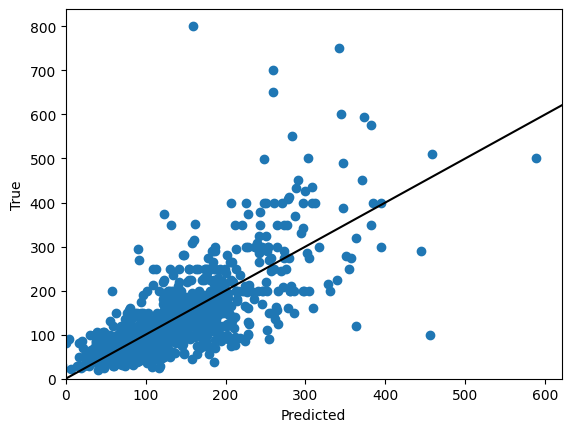

In [ ]:
train_MSE, test_MSE, test_pred = run_OLS(train_y, test_y, train_vals, test_vals)

print("Train MSE\t", str(train_MSE))
print("Test MSE\t", str(test_MSE))

plot_pred_true(test_pred.flatten(), test_y)



---



---


# 6. Location data (10pt)

If you remember, a common refrain in Real Estate is "location, location, location." We're treating Manhattan properties with the same formula as Staten Island!

The most naive way to include location data would be with the categories "latitude" and "longitude" - after all, these are continuous variables, so why not include them in the simplest manner possible?

Load the longitude and lattitude data in, then try to see what the MSE is if you use only these variables,

Train MSE	 10717.388728625885
Test MSE	 10552.152372130282


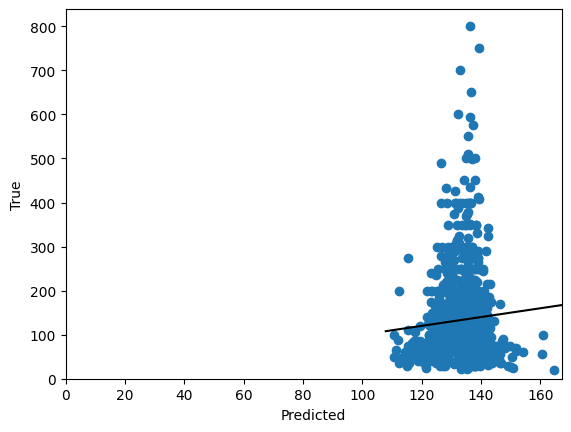

In [ ]:
loc_labels = ['latitude',
             'longitude']


# Your code here
train_loc_vals = train_x.loc[:, loc_labels].fillna('NaN')
test_loc_vals = test_x.loc[:, loc_labels].fillna('NaN')

train_loc_vals = np.asarray(train_loc_vals)
test_loc_vals = np.asarray(test_loc_vals)

train_MSE, test_MSE, test_pred = run_OLS(train_y, test_y, train_loc_vals, test_loc_vals)

print("Train MSE\t", str(train_MSE))
print("Test MSE\t", str(test_MSE))

plot_pred_true(test_pred.flatten(), test_y)

Clearly, this is insufficient. The reality is that price is a highly nonlinear function of location; simply going north or south does not directly translate into rental price.

There are several solutions. We could expand our basis of functions, for instance, to use more than linear functions of longitude and lattitude:

In [ ]:
tr_lat = train_loc_vals[:,0]
tr_long = train_loc_vals[:,1]
train_lv2 = np.transpose( np.vstack([tr_lat, tr_long,
                           tr_lat**2, tr_long**2, np.multiply(tr_lat,tr_long)]) )

te_lat = test_loc_vals[:,0]
te_long = test_loc_vals[:,1]
test_lv2 = np.transpose( np.vstack([te_lat, te_long,
                           te_lat**2, te_long**2, np.multiply(te_lat,te_long)]) )

Train MSE	 9336.12299773242
Test MSE	 9241.494485033905


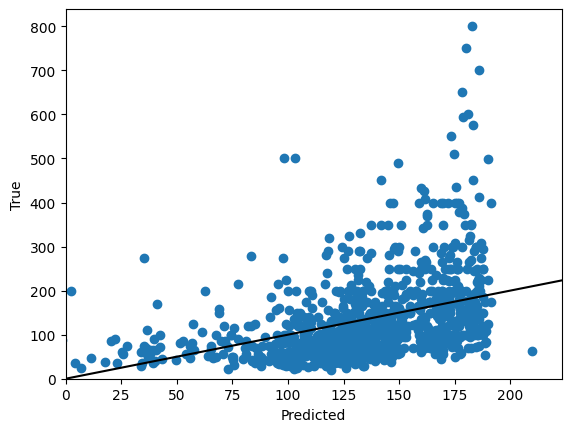

In [ ]:
train_MSE, test_MSE, test_pred = run_OLS(train_y, test_y, train_lv2, test_lv2)

print("Train MSE\t", str(train_MSE))
print("Test MSE\t", str(test_MSE))

plot_pred_true(test_pred.flatten(), test_y)

This helps somewhat with a small nonlinear basis, and a lot with a large basis.

There are many different types of nonlinear location basis, of course. We've used a simple polynomial basis above. We might choose a Fourier basis instead; this is especially useful if we believe our data will have strong periodic components, but really this will handle any data in a confined space (assuming our data is sufficiently densely sampled to avoid horrible artefacts).

There is a far simpler basis, however, which will work great in our case. Imagine a function that has value $1$ within a specific, closed region - say, an island, or a zip code. Now imagine we have a large list of such functions, which collectively tile the entire region of interest. Bonus points if the regions do not overlap, though that is technically not even necessary.

Now, these functions are going to have fewer nice mathematical properties than Fourier features, or wavelets, or even polynomials - two adjacent points will tell us nothing about each other if they are on different sides of one of these artificial borders - but these functions might be very easy to compute. Taking a quick look at the list of columns, it seems we have a number of categorical location parameters to choose from.

  - street
  - neighbourhood
  - neighbourhood_cleansed
  - neighbourhood_group_cleansed
  - city
  - state
  - zipcode
  - market
  - smart_location
  - country_code
  - country
  
Use one of the most granular descriptions available - zipcode - and see if that is a good descriptor of location.

In the next cell, build a model using this parameter ONLY and print the train and test MSE.

Note that it may seem cumbersome to put 'zipcode' in a list, but formatting the one-hot encoding as before ensures the methods are able to handle correct data types (e.g. no data type errors arise between Series vs Dataframe)

In [ ]:
l = ['zipcode']

cats_sets = [train_x.loc[:,i].fillna('NaN').unique() for i in l]
print("Number of categories\t", len(cats_sets[0]))

# Your code here

train_zip = onehot(train_x.loc[:, l[0]].fillna('NaN'), cats_sets[0])
test_zip = onehot(test_x.loc[:, l[0]].fillna('NaN'), cats_sets[0])

print(train_zip.shape)
print(test_zip.shape)


Number of categories	 189
(23313, 189)
(5829, 189)


Now add the intercept  to 'train_zip' & 'test_zip' to create 'train_zip_only' & 'test_zip_only' and then fit your model.

Train MSE	 8600.248282259943
Test MSE	 8671.1756433701


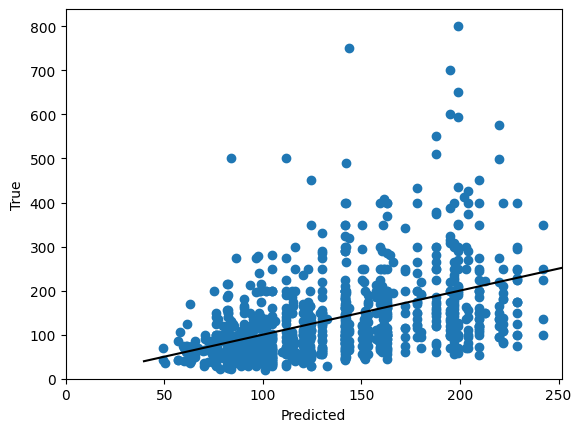

In [ ]:
# Your code here

train_zip_only = np.concatenate((np.ones((train_zip.shape[0],1)), train_zip), axis=1)
test_zip_only = np.concatenate((np.ones((test_zip.shape[0],1)), test_zip), axis=1)

train_MSE, test_MSE, test_pred = run_OLS(train_y, test_y, train_zip_only, test_zip_only)

print("Train MSE\t", str(train_MSE))
print("Test MSE\t", str(test_MSE))

plot_pred_true(test_pred.flatten(), test_y)

It might not look like much, but it's certainly better than raw longitude and lattitude. Compound the zip code data with the features that we've already accumulated, and print out the MSE scores and draw the plots for the full set:

In [ ]:
# Your code here

train_vals = np.concatenate((train_vals, train_zip), axis=1)
test_vals = np.concatenate((test_vals, test_zip), axis=1)

Train MSE	 3920.9091996578186
Test MSE	 4178.635043376734


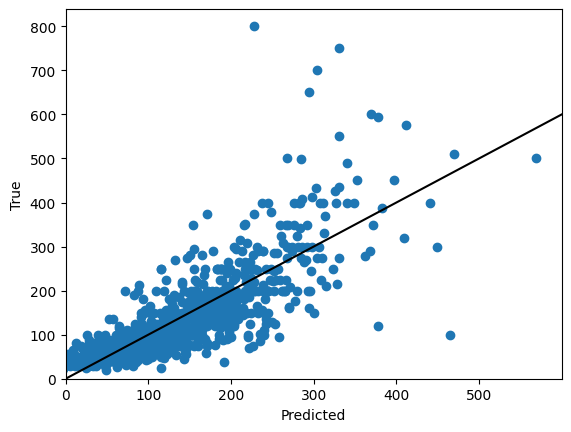

In [ ]:
train_MSE, test_MSE, test_pred = run_OLS(train_y, test_y, train_vals, test_vals)

print("Train MSE\t", str(train_MSE))
print("Test MSE\t", str(test_MSE))

plot_pred_true(test_pred.flatten(), test_y)

This is by far the best result so far. It seems that location brought in some new information, giving us significantly more predictive power.

We are close to the end of all standard techniques (maybe some of the features we've modeled as reals should really be ordinals), but there is one more type of data that we haven't utilized yet.



---



---


# 7. Text data (15pt)


The following columns consist of long-form textual descriptions:

  - name
  - summary
  - space
  - neighborhood_overview
  - notes
  - transit
  - access
  - interaction
  - house_rules

We will experiment with using features from a pretrained neural network to represent this data.
The neural network has learned an internal representation (say, at some hidden layer of the network) that it uses to make its predictions on a different task (such as sentiment prediction for sentences).

We will use this internal representation directly for our task of AirBnB price prediction.
Using an internal representation from an unrelated model as a feature is a common technique known as transfer learning.

We will use pretrained features from the Universal Sentence Encoder (USE), which was designed explicitly for transfer learning to different tasks.
[This paper](https://static.googleusercontent.com/media/research.google.com/en//pubs/archive/46808.pdf) documents how this neural network architecture was designed and trained:
This network consumes text of arbitrary length, and produces a feature vector of length $512$.

We have precomputed these features for all of the columns above into the table "airbnb-use-embeddings.csv".

**Data access:** the data is stored in https://drive.google.com/file/d/1S1ZX9SH1hW7xn-YiRNHt7rxcMGAyVCG0/

**Load Data:** Once you open the link in the brower, make sure you click the "Add shortcut to Drive" and now your google drive should show up the zip file.  Then you run the following code to link colab to your google drive.

The id of each AirBnB listing is provided, along with features with names of the form "column_number:feature_number". That is, the 468th feature of the 5th text data column (also known as the "name" column) will be found at '5:468'.

Returning to the AirBnB dataset, we can import the data into a new dataframe. Since our training data has been shuffled, we use a dataset join to assemble the data below.


In [ ]:
# ! unzip airbnb-use-embeddings.zip

In [ ]:
df_tf = pd.read_csv("airbnb-use-embeddings.csv") # Will take a while to read

In [ ]:
train_all = train_x.merge(df_tf, on='id',how='left')
test_all = test_x.merge(df_tf, on='id',how='left')

In [ ]:
print('Number of original features \t', len(train_x.columns))

train_embed = np.array(train_all.iloc[:, len(train_x.columns):])
test_embed = np.array(test_all.iloc[:, len(train_x.columns):])

print(train_embed.shape)
print(test_embed.shape)

Number of original features 	 93
(23313, 4608)
(5829, 4608)


To find out how useful these parameters are (or aren't), fit a linear model of price as a function of embedding only (with intercept term). Keep in mind that due to the sheer number of parameters to fit, this step may take several minutes.

Train MSE	 5019.384681447042
Test MSE	 7942.522614552754


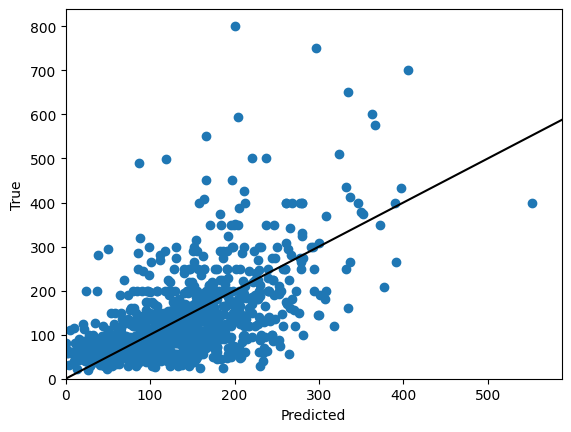

In [ ]:
train_embed_only = np.concatenate((np.ones((train_embed.shape[0],1)), train_embed), axis=1)
test_embed_only = np.concatenate((np.ones((test_embed.shape[0],1)), test_embed), axis=1)

train_MSE, test_MSE, test_pred = run_OLS(train_y, test_y, train_embed_only, test_embed_only)

print("Train MSE\t", str(train_MSE))
print("Test MSE\t", str(test_MSE))

plot_pred_true(test_pred.flatten(), test_y)

Two things are readily apparent: this embedding provides a lot of information, but we are massively overfitting. This is to be expected: after all we have  4689  parameters to fit, but only  20000  training points.

Now, it's important to know whether this embedding is just capturing information more succinctly stored in the other columns, or whether its capturing something genuinely novel. For that, you will need to fit a function using all of the parameters currently at your disposal, then compute MSE and plot the predicted vs expected score. This step may take several minutes.

In [ ]:
train_vals = np.concatenate((train_vals, train_embed), axis=1)
test_vals = np.concatenate((test_vals, test_embed), axis=1)

print(train_vals.shape)
print(test_vals.shape)

(23313, 4903)
(5829, 4903)


Train MSE	 2807.9624101113054
Test MSE	 4743.126240606015


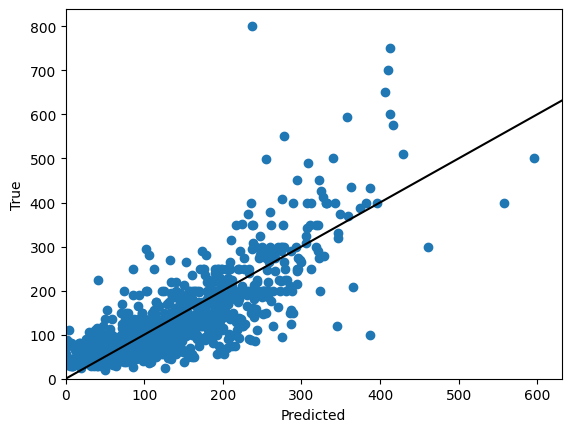

In [ ]:
train_MSE, test_MSE, test_pred = run_OLS(train_y, test_y, train_vals, test_vals)

print("Train MSE\t", str(train_MSE))
print("Test MSE\t", str(test_MSE))

plot_pred_true(test_pred.flatten(), test_y)



---



---


# 8. Feature Engieering

In the above parts, we have seen the strength of adding more (useful) features in improving both training and test performance. In this part, we want to test the idea of whether we can further improve our model by not adding more features, but making wise use of the features.

First, we prepare a data-subsampled dataset with only 20% of the training and test data points retained. This saves time for us to test more settings.

In [ ]:
data_sampling_ratio = 0.20
train_n_rows_to_sample = int(round(data_sampling_ratio * train_vals.shape[0]))
train_idx_rows_to_sample = rand.sample(list(range(len(train_vals))), train_n_rows_to_sample)

train_vals_real_small = train_vals_real[train_idx_rows_to_sample, :]
train_vals_from_string_small = train_vals_from_string[train_idx_rows_to_sample, :]
train_bv_small = train_bv[train_idx_rows_to_sample, :]
train_cat_vals_small = train_cat_vals[train_idx_rows_to_sample, :]
train_set_vals_small = train_set_vals[train_idx_rows_to_sample, :]
train_zip_small = train_zip[train_idx_rows_to_sample, :]
train_embed_small = train_embed[train_idx_rows_to_sample, :]

train_vals_small = np.concatenate((train_vals_real_small,
                train_vals_from_string_small,
                train_bv_small,
                train_cat_vals_small,
                train_set_vals_small,
                train_zip_small,
                train_embed_small,
                np.ones(len(train_vals_real_small)).reshape([len(train_vals_real_small),1]) ), axis=1)

train_y_small = train_y.iloc[train_idx_rows_to_sample]

print(train_vals_small.shape)
print(train_y_small.shape)

(4663, 4904)
(4663,)


In [ ]:
# Repeat with test set
data_sampling_ratio = 0.20
test_n_rows_to_sample = int(round(data_sampling_ratio * test_vals.shape[0]))
test_idx_rows_to_sample = rand.sample(list(range(len(test_vals))), test_n_rows_to_sample)

test_vals_real_small = test_vals_real[test_idx_rows_to_sample, :]
test_vals_from_string_small = test_vals_from_string[test_idx_rows_to_sample, :]
test_bv_small = test_bv[test_idx_rows_to_sample, :]
test_cat_vals_small = test_cat_vals[test_idx_rows_to_sample, :]
test_set_vals_small = test_set_vals[test_idx_rows_to_sample, :]
test_zip_small = test_zip[test_idx_rows_to_sample, :]
test_embed_small = test_embed[test_idx_rows_to_sample, :]

test_vals_small = np.concatenate((test_vals_real_small,
                test_vals_from_string_small,
                test_bv_small,
                test_cat_vals_small,
                test_set_vals_small,
                test_zip_small,
                test_embed_small,
                np.ones(len(test_vals_real_small)).reshape([len(test_vals_real_small),1]) ), axis=1)

test_y_small = test_y.iloc[test_idx_rows_to_sample]

print(test_vals_small.shape)
print(test_y_small.shape)

(1166, 4904)
(1166,)


Then we train the linear regressor on the subsampled training set, and take a look at training and test MSEs. Despite the fact we shrunk our dataset, **this step may take a few minutes**.

Train MSE	 2.793877873410169e-12
Test MSE	 293702.3892087842


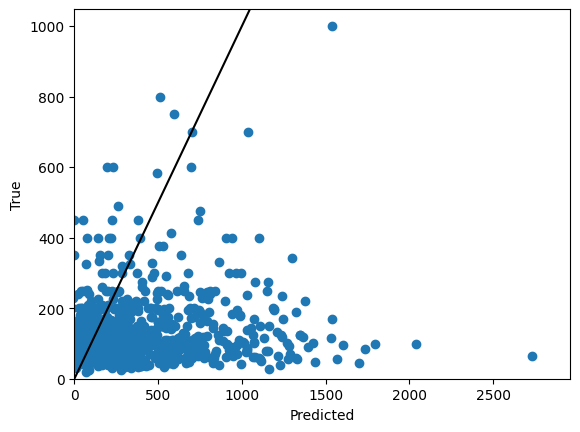

In [ ]:
train_MSE_small, test_MSE_small, test_pred_small = run_OLS(train_y_small, test_y_small, train_vals_small, test_vals_small)

print("Train MSE\t", str(train_MSE_small))
print("Test MSE\t", str(test_MSE_small))

plot_pred_true(test_pred_small.flatten(), test_y_small)



---


## Q8.1: (10pt)
Compare the training and test MSEs on the data-subsampled dataset with those on the original dataset: the one that includes all data points and all features, as you did in the cell above the heading of this section. For these two fitted models, are they overfitting or underfitting? Which one over/underfits more? Why?

## Your response:

It is very clear that we have a massive overfitting issue in the subsampled dataset, which can be read from the ratio of testing MSE to training MSE being on a magnitude of $10^{14}$. The original dataset can be said to have a slight underfitting issue with how large the MSEs are, but this is bound to occur given the number of samples and features we are using. One could argue the model isn't underfitting on that basis, but I still claim a slight underfitting.



---


## Q8.2: (10pt)

In the next cell, test on a collection of the number of text embedding features to sample, and plot the change of train and test MSEs. This may take several minutes, but you would not need to do it multiple times as long as your code in the above cell works well.

In [ ]:
train_MSE_sub_all = []
test_MSE_sub_all = []

# the collection of number of text embedding features to sample
n_embed_to_sample_all = [10, 50, 100, 200, 500, 1000]#, 2000], 3000, 4000]

for n_embed_to_sample in n_embed_to_sample_all:
    print("Number of text embedding features to sample: ", str(n_embed_to_sample))

    # your code here
    idx_embed_to_sample = rand.sample(list(range(train_embed_small.shape[1])), n_embed_to_sample)

    train_embed_sub = train_embed_small[:, idx_embed_to_sample]
    test_embed_sub = test_embed_small[:, idx_embed_to_sample]

    train_vals_sub = np.concatenate((train_vals_real_small,
                train_vals_from_string_small,
                train_bv_small,
                train_cat_vals_small,
                train_set_vals_small,
                train_zip_small,
                train_embed_sub,
                np.ones(len(train_vals_real_small)).reshape([len(train_vals_real_small),1]) ), axis=1)

    test_vals_sub = np.concatenate((test_vals_real_small,
                test_vals_from_string_small,
                test_bv_small,
                test_cat_vals_small,
                test_set_vals_small,
                test_zip_small,
                test_embed_sub,
                np.ones(len(test_vals_real_small)).reshape([len(test_vals_real_small),1]) ), axis=1)

    train_MSE, test_MSE, test_pred_sub = run_OLS(train_y_small, test_y_small, train_vals_sub, test_vals_sub)

    print("Train MSE\t", str(train_MSE))
    print("Test MSE\t", str(test_MSE))

    train_MSE_sub_all.append(train_MSE)
    test_MSE_sub_all.append(test_MSE)

Number of text embedding features to sample:  10
Train MSE	 3622.8099936564427
Test MSE	 4737.006754614024
Number of text embedding features to sample:  50
Train MSE	 3586.693391120786
Test MSE	 4762.9296138037935
Number of text embedding features to sample:  100
Train MSE	 3495.109389302922
Test MSE	 4847.095984851288
Number of text embedding features to sample:  200
Train MSE	 3396.4761008273276
Test MSE	 4854.660127790009
Number of text embedding features to sample:  500
Train MSE	 3073.228444580161
Test MSE	 5283.235859740498
Number of text embedding features to sample:  1000
Train MSE	 2579.863362752053
Test MSE	 5783.941551762289


In the next cell, plot the change of train and test MSEs with the number of sampled features, together with two horizontal lines showing the train and test MSEs on the entire data-subsampled dataset (i.e., not feature-subsampled).

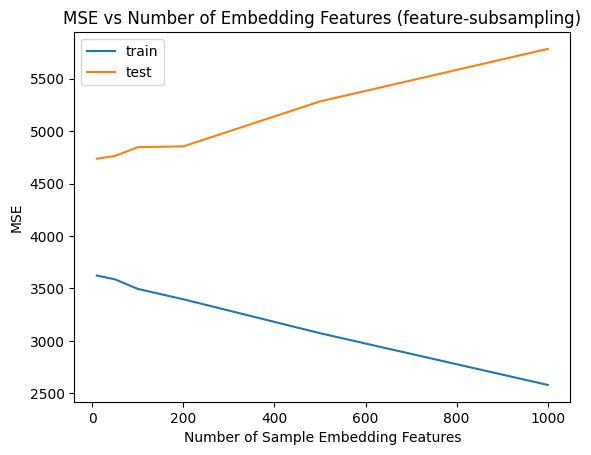

In [ ]:
plt.plot(n_embed_to_sample_all, train_MSE_sub_all)
plt.plot(n_embed_to_sample_all, test_MSE_sub_all)
#plt.yscale('log')
plt.xlabel('Number of Sample Embedding Features')
plt.ylabel('MSE')
plt.title('MSE vs Number of Embedding Features')
plt.legend(['train','test'])
plt.show()


- In the plot you get above:does the model over/underfit worse when the number of sampled text embedding feature increases?  Why?
- Compared to the model performance on the entire data-subsampled dataset (i.e., not feature-subsampled), how does feature subsampling work, in terms of prediction error and generalization?

## Your response:

The model starts to overfit more as we increase the number of text embeds as seen by the increasing divide between the training and testing MSEs, where the training MSE seems to be linear-inversely proportional to added features and testing MSE is exponential-directly proportional to added features.

We can see then that this embedding features is a good solution to overfitting by seeing when certain breakpoints are met in the MSEs. Too little and it's like not having any of the features, too much and our model is too generalized. We can likely study the slope of the testing MSE vs sample number to get a good estimate of where a decrease in training MSE becomes optimal (i.e. not so much overfitting with exponential increase in testing MSE).

As a side note, during a preliminary run on this data, I had an output different from this one where the training data was decreasing exponentially, giving me a slightly different analysis to the one above. I'm not sure why it's different now given I didn't change the code at all (likely the randomness). As it was, the diffence between PCA and embedded was this exponential vs linear descent, but here we clearly see this isn't the case.



---


## Q8.3: (10pt)

Finally, we explore a "smarter" way of reducing the number of features using Principal Component Analysis (PCA) to embed the features. PCA projects the data onto a subspace of maximal variance, preserving as much signal as possible in fewer dimensions. We'll cover PCA later in the course.

In the next cell, compute the Singular Value Decomposition (SVD) of the embedding features by using np.linalg.svd(). It may take a couple of trys to converge, so be aware that this cell **may take several minutes to run.**

In the next cell, test on a collection of the rank of the PCA to use, and plot the change of train and test MSEs. **This may take several minutes.** In particular, take the first $k$ columns of $V$ where $USV^T$ is the SVD of the embedding feature matrix and right multiply the embedding feature matrix with the first $k$ columns of $V$.

In [ ]:
train_MSE_pca_all = []
test_MSE_pca_all = []

print('Train MSE on the data-subsampled dataset \t', str(train_MSE_small))
print('Test MSE on the data-subsampled dataset \t', str(test_MSE_small))

k_all = [10, 50, 100, 500, 1000]#, 2000], 3000, 4000]

U, S, V = np.linalg.svd(train_embed_small)

for k in k_all:
    print("k =", k)

    # Your code here

    V_k = V[:, :k]

    train_embed_pca = np.matmul(train_embed_small, V_k)
    test_embed_pca = np.matmul(test_embed_small, V_k)

    train_vals_pca = np.concatenate((train_vals_real_small,
                train_vals_from_string_small,
                train_bv_small,
                train_cat_vals_small,
                train_set_vals_small,
                train_zip_small,
                train_embed_pca,
                np.ones(len(train_vals_real_small)).reshape([len(train_vals_real_small),1]) ), axis=1)

    test_vals_pca = np.concatenate((test_vals_real_small,
                test_vals_from_string_small,
                test_bv_small,
                test_cat_vals_small,
                test_set_vals_small,
                test_zip_small,
                test_embed_pca,
                np.ones(len(test_vals_real_small)).reshape([len(test_vals_real_small),1]) ), axis=1)

    train_MSE, test_MSE, test_pred_sub = run_OLS(train_y_small, test_y_small, train_vals_pca, test_vals_pca)

    print("Train MSE\t", str(train_MSE))
    print("Test MSE\t", str(test_MSE))

    train_MSE_pca_all.append(train_MSE)
    test_MSE_pca_all.append(test_MSE)


Train MSE on the data-subsampled dataset 	 2.793877873410169e-12
Test MSE on the data-subsampled dataset 	 293702.3892087842
k = 10
Train MSE	 3640.904304549173
Test MSE	 4780.853172589287
k = 50
Train MSE	 3574.317936101056
Test MSE	 4821.404930977092
k = 100
Train MSE	 3490.7190997945886
Test MSE	 4846.064643489924
k = 500
Train MSE	 3047.732536934927
Test MSE	 5131.880251871071
k = 1000
Train MSE	 2577.96992211609
Test MSE	 5933.847581278237


In the next cell, plot the change of train and test MSEs in the PCA case, in the same way as random sampling.

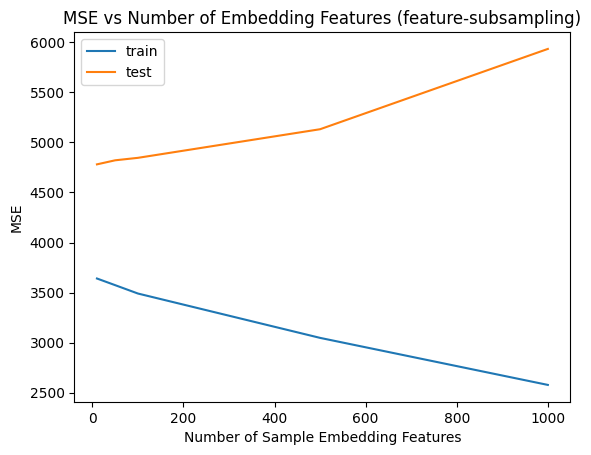

In [ ]:
plt.plot(k_all, train_MSE_pca_all)
plt.plot(k_all, test_MSE_pca_all)
plt.xlabel('Number of Sample Embedding Features')
plt.ylabel('MSE')
plt.title('MSE vs Number of Embedding Features (feature-subsampling)')
plt.legend(['train','test'])
plt.show()


- In the PCA plot you get above, does the model over/underfits worse when the number of sampled text embedding feature increases?
- Compared to randomly sampling the text embedding features, how does PCA works, in terms of prediction error and generalization?

## Your response:

We get the same kind of splitting of training and testing MSE from an increase in features. Looking at the raw data, we even see that the graphs have the same trajectory throughout. All and all, it seems the only major difference is in runtime, where the PCA takes roughly double the time of the sampled text embedding (but this may be a memory issue on my end). Most of this runtime comes from running the SVD, but it seems each OLS run takes longer as well (due to the matrix multiplication).

With a similar output, we can assume the same conclusions made above for the embedding features.